# Full connectivity matrix

First and second moment of the connectivity matrices for homogeneous and heterogeneous networks, and connectivity matrices

In [4]:
# Get and load color map (handles if it is in another folder)
from pathlib import Path
import sys
import matplotlib.pyplot as plt

cwd = Path.cwd()
while not (cwd / "color_map.py").exists():
    cwd = cwd.parent
sys.path.insert(0, str(cwd))
from color_map import make_color_map

v_rest = [-22, -17, -12.3, -8.5]
pqif_vector = [0, 0.25, 0.5, 0.75, 1]
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'

# Load matplotlib style (handles if in another folder)
from pathlib import Path
cwd = Path.cwd()
while not (cwd / "plos.mplstyle").exists():
    cwd = cwd.parent

style_path = Path(cwd / 'plos.mplstyle')
plt.style.use(style_path)

In [1]:
from config import SimParam, Config  # Classes
from pathlib import Path

all_pqif = [0, 0.25, 0.5, 0.75, 1]
seeds = range(50)

# Oscillations
oscillation_sims = [
    SimParam(1, -8.5, 14.44),
    SimParam(2, -12.3, 10.68),
    SimParam(3, -17.0, 8.65),
    SimParam(4, -22.0, 7.18),
]

oscillations = Config(
    name="oscillations",
    sims=oscillation_sims,
    pqif_numbers=all_pqif,
    seed_numbers=seeds
)

print(repr(oscillations))

# Sequences
sequence_sims = [
    SimParam(9, -8.5, 14.44),
    SimParam(10, -12.3, 10.68),
    SimParam(11, -17.0, 8.65),
    SimParam(12, -22.0, 7.18),
]

sequences = Config(
    name="sequences",
    sims=sequence_sims,
    pqif_numbers=all_pqif,
    seed_numbers=seeds
)

print(repr(sequences))

configs = [oscillations, sequences]



Config name: oscillations
  pqif: [0, 0.25, 0.5, 0.75, 1]
  simulations: 1 : (vrest=-8.5, gain=14.44), 2 : (vrest=-12.3, gain=10.68), 3 : (vrest=-17.0, gain=8.65), 4 : (vrest=-22.0, gain=7.18)
  across 50 seeds
Config name: sequences
  pqif: [0, 0.25, 0.5, 0.75, 1]
  simulations: 9 : (vrest=-8.5, gain=14.44), 10 : (vrest=-12.3, gain=10.68), 11 : (vrest=-17.0, gain=8.65), 12 : (vrest=-22.0, gain=7.18)
  across 50 seeds


In [6]:
base_path = Path(r"J:\ordinary_simulations")  # Path to simulation files 
base_path.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd


weights_filtered_dict = {}
rows = []

for i, cfg in enumerate(configs):
    print(f"{i}: {cfg.name}")

    for sim_param, pqif, seed in cfg.iter_params():
        sim = sim_param.sim
        vrest = sim_param.vrest
        gain = sim_param.gain

        
        simulation_id = f'{cfg.name}_sim_{sim}_pqif_{pqif}_seed_{seed}'  # Shared across dataframe and dictionary

        # ------------------------------ Initial matrix (with zero weights) ------------------------------
        file_path_iloop_0 = base_path / f"simulation_{sim}\simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_0_seed_{seed}"

        M = np.loadtxt(file_path_iloop_0, delimiter=',')

        # ------------------------------ Info about sparsity ------------------------------

        zeros = M == 0  # matrix indicating which weights were initialized to zero
        num_zero_weights = np.sum(zeros)
        num_non_zero_weights = np.sum(~zeros)
        frac_zero_weights = f"{np.sum(zeros) / M.size:.2f}" # should be around 0.7

        # ------------------------------ Matrix after training ------------------------------

        # Load matrix
        file_path_iloop_11 = base_path / f'simulation_{sim}\simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_11_seed_{seed}'

        W_unfiltered = np.loadtxt(file_path_iloop_11, delimiter=',')

        # ------------------------------ Filtered data: Exclude weights initialized to zero ------------------------------
        
        W_filtered = W_unfiltered[~zeros]  # Omit zeros, becomes 1D
        weights_filtered_dict[simulation_id] = W_filtered  # Add filtered weights to dictionary; is flattened

        mean = np.mean(W_filtered)  # Mean
        std_pop = np.std(W_filtered)  # Standard deviation (population)
        std_sample = np.std(W_filtered, ddof=1)  # Standard deviation (sample)


        # ------------------------------ Final stats ------------------------------


        row = [simulation_id, cfg.name, sim, vrest, gain, 
                pqif, seed, mean, std_pop, std_sample, 
                num_zero_weights, num_non_zero_weights, frac_zero_weights]  # Store all data associated with the connectivity matrix + a simulationID to the weights in dictionary
        rows.append(row)  # Append row to what becomes the dataframe later

# ------------------------------ Make dataframe ------------------------------

columns = ['config', 'dynamic', 'simulation', 'vrest', 'slope', 
           'pqif', 'seed',  'mean', 'std_pop', 'std_sample', 
           'num_zero_weights', 'num_non_zero_weights', 'frac_zero_weights']
df = pd.DataFrame(rows, columns=columns)
df.to_csv("statistics_connectivity.csv", index=False)

# Part to copy for reusing csv
loaded_df = pd.read_csv("statistics_connectivity.csv") 
wDF = loaded_df.copy()
wDF.head(5)

0: oscillations
1: sequences


,config,dynamic,simulation,vrest,slope,pqif,seed,mean,std_pop,std_sample,num_zero_weights,num_non_zero_weights,frac_zero_weights
0,oscillations_sim_1_pqif_0_seed_0,oscillations,1,-8.5,14.44,0.0,0,0.000267,0.426141,0.426159,28062,11938,0.7
1,oscillations_sim_1_pqif_0_seed_1,oscillations,1,-8.5,14.44,0.0,1,-0.000349,0.426364,0.426382,28063,11937,0.7
2,oscillations_sim_1_pqif_0_seed_2,oscillations,1,-8.5,14.44,0.0,2,0.000812,0.399953,0.399970,28070,11930,0.7
3,oscillations_sim_1_pqif_0_seed_3,oscillations,1,-8.5,14.44,0.0,3,0.000729,0.420193,0.420211,28062,11938,0.7
4,oscillations_sim_1_pqif_0_seed_4,oscillations,1,-8.5,14.44,0.0,4,0.000024,0.441818,0.441836,28068,11932,0.7


## Connectivity matrices

Here I average across seeds and plot connectivity matrices for each dyn * simulation * pqif

0: oscillations


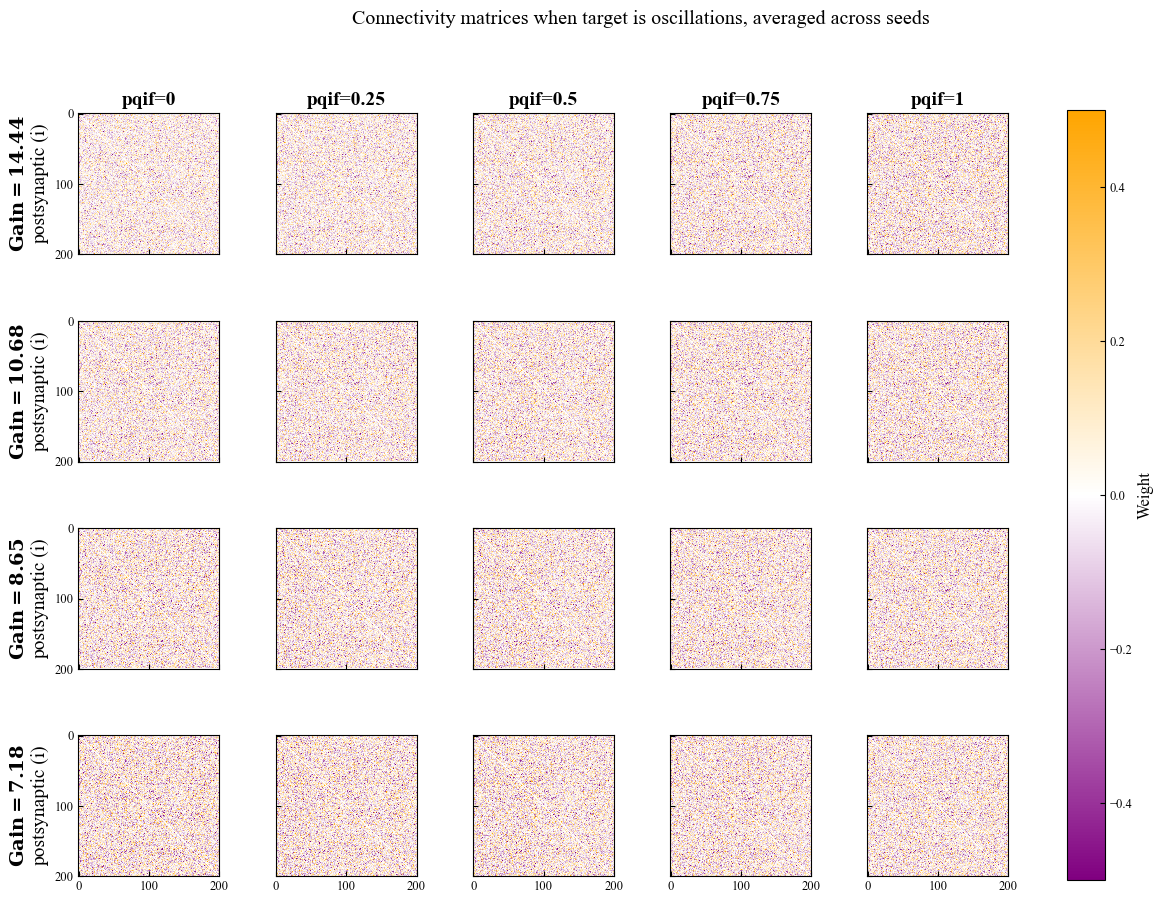

1: sequences


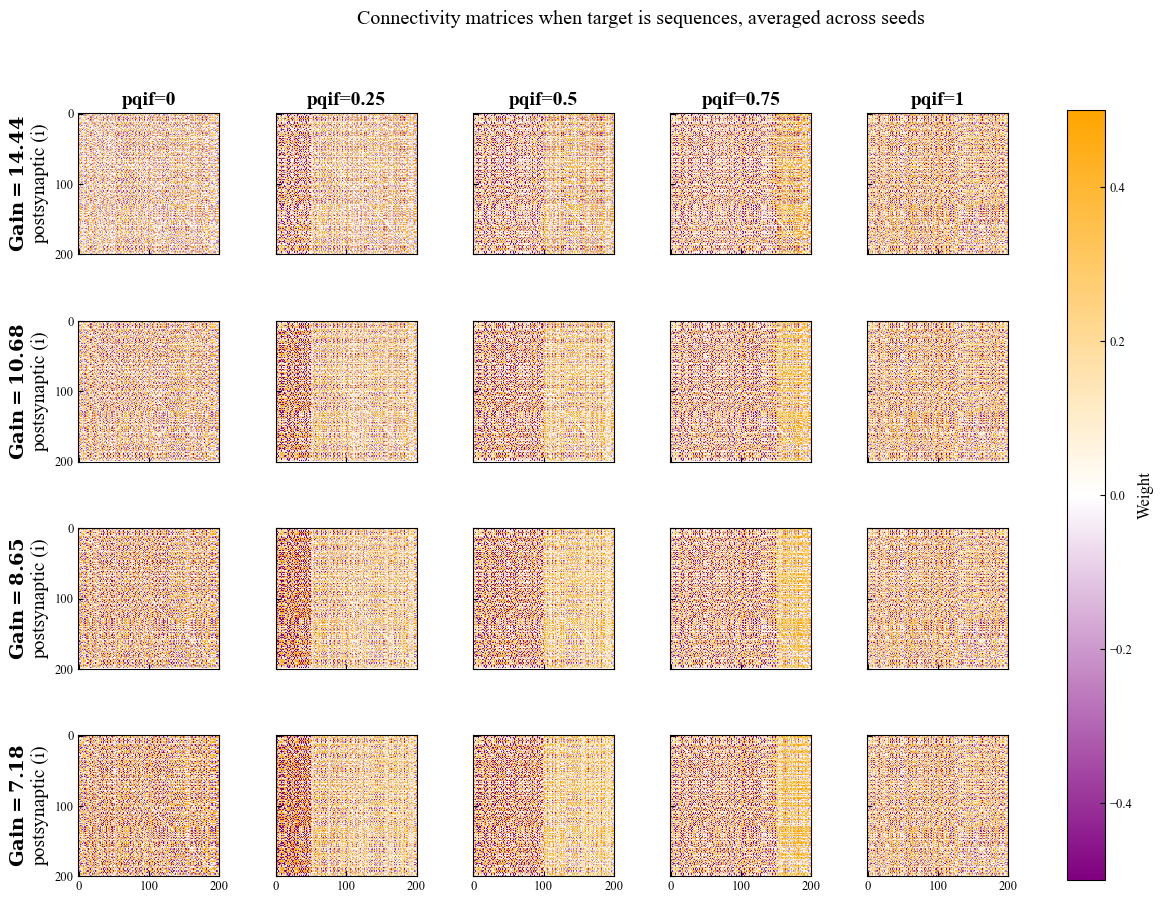

In [5]:
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

base_path = Path(r"J:\ordinary_simulations")  # Path to simulation files 
base_path.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd

gains = oscillations.gains
namelist_slope = [f"Gain = {f}" for f in gains]
pqif_numbers = oscillations.pqif_numbers
namelist_pqif = [f"pqif={p}" for p in pqif_numbers]

for i, cfg in enumerate(configs):
        fig, axes = plt.subplots(nrows=len(cfg.sims), ncols=len(cfg.pqif_numbers), figsize=(15,10), sharex=True, sharey=True)
        fig.subplots_adjust(wspace=0.4, hspace=0.4)
        figname = f"{cfg.name}_connectivity_matrix.svg"
        print(f"{i}: {cfg.name}")

        for idx, sim_param in enumerate(cfg.sims):

                sim = sim_param.sim
                gain = sim_param.gain

                for jdx, pqif in enumerate(cfg.pqif_numbers):

                        ax = axes[idx, jdx]
                        matrices = []

                        for seed in cfg.seed_numbers:

                                # J becomes a list of matrices across seeds for this (dyn, sim, pqif)
                                J = np.loadtxt(base_path / f"simulation_{sim}\simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_11_seed_{seed}", delimiter=",")
                                matrices.append(J)

                        # ------------------------------------------------------------

                        #  Get averaged matrices
                        #  Get averaged matrices

                        matrices = np.array(matrices)  # array of 50 matrices (one per seed)
                        nonzero_mask = matrices != 0  # boolean array with true if connectivity exist, false if not
                        sum_weights = np.sum(matrices, axis=0)  # sums across seeds, so it becomes one matrix where each entry is summed
                        count_nonzero = np.sum(nonzero_mask, axis=0)  # Each entry: in how many seeds did this synapse exist

                        j_avg = np.divide(  
                                # final averaging: sum of weights divided by how many seeds this synapse exist - typical strength for this entry, instead of avg across networks 
                                sum_weights,
                                count_nonzero,
                                out=np.zeros_like(sum_weights, dtype=float),
                                where=count_nonzero != 0
                        )
                                                

                        # ------------------------------------------------------------

                        # Color map for this figure

                        j_plot = np.ma.masked_where(j_avg == 0, j_avg) # Mask true zeros so they appear white / blank
                        colors = ["purple", "white", "orange"] # Define new endpoints
                        cmap2 = mcolors.LinearSegmentedColormap.from_list("purple_orange", colors, N=256)
                        cmap2 = cmap2.copy()
                        cmap2.set_bad(color="white") # Make masked values white


                        # ------------------------------------------------------------
                        # Plot matrix, ax changes depending on (dyn, sim, pqif) condition
                        sc = ax.imshow(
                        j_plot,
                        cmap=cmap2,
                        vmin=-0.5,
                        vmax=0.5,
                        origin="upper",
                        interpolation="none",
                        aspect="equal",
                        rasterized=True
                        )

                        ax.set_xticks([0, 100, 200])
                        ax.set_yticks([0, 100, 200])

                        if jdx == 0:
                                ax.set_ylabel(
                                        f"$\\mathbf{{{namelist_slope[idx]}}}$\npostsynaptic (i)",
                                        fontsize=14
                                        )
                        if idx == 0:
                                ax.set_title(namelist_pqif[jdx], fontsize=14, fontweight='bold')


                        if idx < 3:
                                ax.set_xlabel("")

                        if jdx > 0:
                                ax.set_ylabel("")


        plt.suptitle(f"Connectivity matrices when target is {cfg.name}, averaged across seeds")
        plt.colorbar(sc, ax=axes.ravel().tolist(), label="Weight")
        # full_path = os.path.join(figure_folder, figname)
        # plt.savefig(full_path, format="svg")
        plt.show()



## Homogeneous networks

### Histograms of weight distributions

Used seed [2]


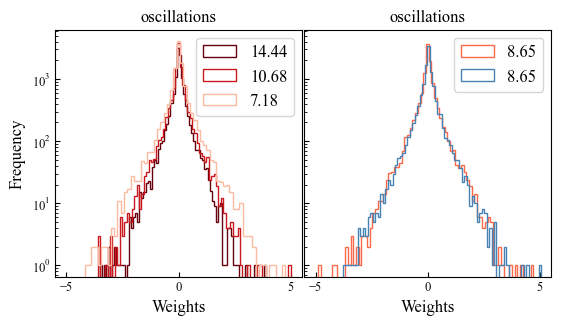

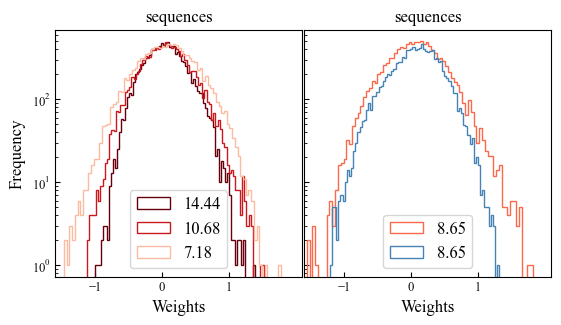

In [6]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib
from brokenaxes import brokenaxes
import matplotlib.lines as mlines
from pathlib import Path

# Load matplotlib style
plt.style.use('plos.mplstyle')

# Import and load color map
from color_map import make_color_map
v_rest = [-22, -17, -12.3, -8.5]
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest

pqif_vector = [0, 0.25, 0.5, 0.75, 1]
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'

# Base path
base_path = Path(r"J:\ordinary_simulations")  # ordinary simulations
base_path.mkdir(parents=True, exist_ok=True)

# Figure path
figure_folder = 'figures_all/figures_june'
figure_folder = 'figures_all/final_figures_thesis'  # Figure path
loaded_df = pd.read_csv("statistics_connectivity.csv")  # Get csv with the stats

wDF = loaded_df.copy()

# ------------------------------------------------------------

# Loop variables

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = [10.74]
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]
pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]
dynamics = ['oscillations', 'sequences']



# ------------------------------------------------------------

# Seed
seed_number = [random.randint(1, 49)] # randomize which seed we use
print(f"Used seed {seed_number}")

# rows = []

# ------------------------------------------------------------

# Figure loop

for dyn in dynamics:

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]

    figname = f"{dyn}_homogenous_histo_weights_filtered.svg"

    #### Create figure and axes

    fig, (ax1, ax2) = plt.subplots(
        nrows=1, ncols=2,
        # figsize=(10,4),  # TODO review
        sharey=True
    )

    fig.subplots_adjust(
    wspace=0.01
    )


    #### Figure control flow

    for sim, vr, f in zip(simulation_number, vrest, slope):
        for pqif in pqif_homogenous:
            for seed in seed_number:

                # Take out values to plot

                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif) & (wDF['seed'] == seed)]  # Current row of dataframe with metadata
                ID = df_filtered['simulationID'].item()  # Get simulation ID
                current_weights = weights_filtered_dict[ID]  # Get flattened weights corresponding to that ID

                # ------------------------------------------------------------

                #### Color control flow
                if pqif == 1:
                    colors = 'steelblue'
                else:
                    colors = color_map_vrest[vr]

                if pqif == 0 and f in [14.44, 10.68, 7.18]:  # Left

                    if sim == simulation_number[0]:  # LIF header in legend
                        label = f"LIF\n$F'$={f}"
                    else:
                        label = f"$F'$={f}"

                    ax1.hist(current_weights, bins=80, log=True, color=colors, alpha=1, linewidth=1, histtype='step', label=f)

                    
                if f == 8.65:  # Right
                    if pqif == 0:
                        label = f"LIF\n$F'$={f}"
                    else:
                        label = 'QIF'

                    ax2.hist(current_weights, bins=80, log=False, color=colors, alpha=1, linewidth=1, histtype='step', label=f)

                else:  # Ignore others
                    continue


    #### Shared formatting

    if dyn == 'oscillations':
        tick_positions = [-5, 0, 5]
        xlim = (-5.5, 5.5)
    elif dyn == 'sequences':
        tick_positions = [-1, 0, 1]
        xlim = (-1.6, 2.1)

    for ax in (ax1, ax2):
        ax.set_xlabel("Weights")
        ax.set_xticks(tick_positions)
        ax.set_xlim(xlim)
        ax.set_box_aspect(1)
        ax.set_title(dyn)
        ax.legend()
    ax1.set_ylabel("Frequency")


    
    #### Save
    full_path = os.path.join(figure_folder, figname)
    # plt.legend()
    plt.savefig(full_path, format="svg")

    # plt.tight_layout()
    plt.show()



# 7

### Standard deviation and mean of weights

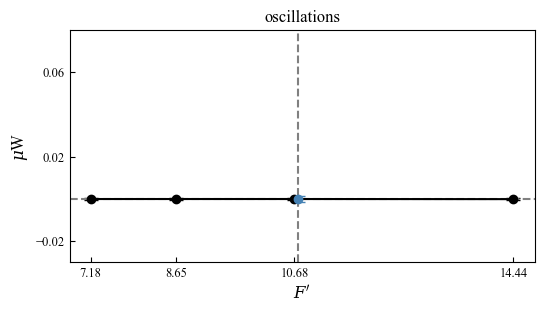

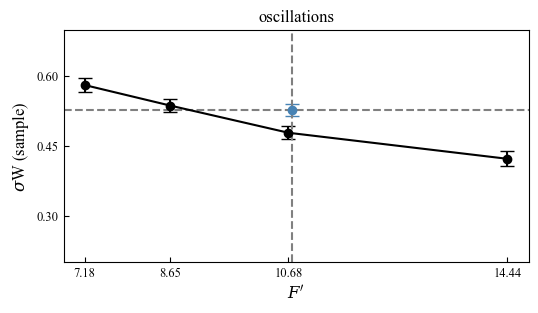

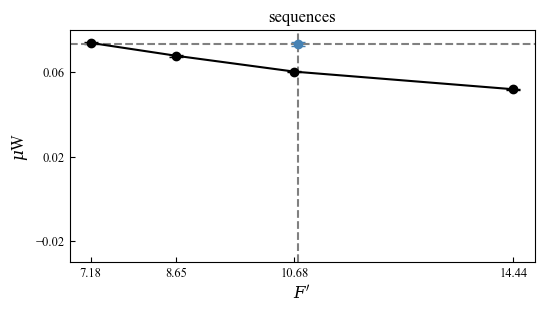

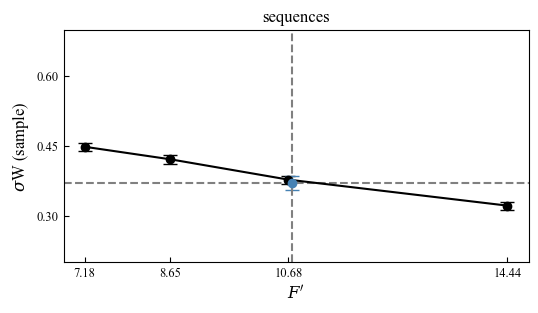

In [8]:
# ========== Standard deviation or Mean of weights vs. slope for homogenous networks ==========

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib
from brokenaxes import brokenaxes
import matplotlib.lines as mlines
from pathlib import Path

# Load matplotlib style
plt.style.use('plos.mplstyle')

# Import and load color map
from color_map import make_color_map
v_rest = [-22, -17, -12.3, -8.5]
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest

pqif_vector = [0, 0.25, 0.5, 0.75, 1]
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'

# Base path
base_path = Path(r"J:\ordinary_simulations")  # ordinary simulations
base_path.mkdir(parents=True, exist_ok=True)

# Figure path
figure_folder = 'figures_all/figures_june'
figure_folder = 'figures_all/final_figures_thesis'  # Figure path
loaded_df = pd.read_csv("statistics_connectivity.csv")  # Get csv with the stats

wDF = loaded_df.copy()


# ------------------------------------------------------------

# Loop variables 

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]
pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]
dynamics = ['oscillations', 'sequences']
seed_number = [i for i in range(0, 50)]
columns = ['mean', 'std_sample']
x_ticks = [14.44, 10.68, 8.65, 7.18]

# ------------------------------------------------------------

# Figure loop

for dyn in dynamics:

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]

    #### Plot same figures for both STD and mean
    for c in columns:

        figname = f"{dyn}_homogenous_{c}-vs-slope_filtered_rectangle.svg"
        fig, ax = plt.subplots(figsize=(6, 4))


        for pqif in pqif_homogenous:

            y = []
            yerr = []
            x = slope


            for sim, vr, f in zip(simulation_number, vrest, slope):


                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif)]  # Current row of dataframe with metadata. Include all seeds since we want errorbars

                # Y: Mean of Y
                y_i = df_filtered[c].mean()

                # Y-error: STD of Y
                yerr_i = df_filtered[c].std()  # sample std by default

                if pqif == 0: # For LIF: Make list across slope
                    y.append(y_i)
                    yerr.append(yerr_i)

                elif pqif == 1:  # Only one value for QIF since it is the same in each simulation
                    y = y_i
                    yerr = yerr_i

            colors = color_map_pqif[pqif]

            #### Title and labels depending on if STD or mean 

            if c == 'std_sample':
                xlabel = f"$F'$"
                ylabel = f"$\sigma$W (sample)"
                ax.set_yticks(np.linspace(0.3, 0.6, 3))
                ax.set_ylim(0.2, 0.7)

            elif c == "mean":
                xlabel = f"$F'$"
                ylabel = f"$\mu$W"
                ax.set_yticks(np.linspace(-0.02, 0.06, 3))
                ax.set_ylim(-0.03, 0.08)

            #### Plot values on ax

            if pqif == 0:
                label = 'LIF'
                ax.errorbar(x, y, yerr, fmt='o-', capsize=5, color=colors, label=label)

            elif pqif == 1:
                label = 'QIF'
                ax.errorbar(slope_qif, y, yerr, fmt='o', capsize=5, color=colors, label=label)
                ax.axhline(y, color='gray', linestyle='--', label="Similar F-I curves")
                ax.axvline(slope_qif, color='gray', linestyle='--', label="Matched gain")


        ax.set_xticks(x_ticks)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_box_aspect(0.5)
        ax.set_title(dyn)


        full_path = os.path.join(figure_folder, figname)
        plt.savefig(full_path, format="svg")
        plt.show()



## Heterogenous

### Standard deviation and mean of weights

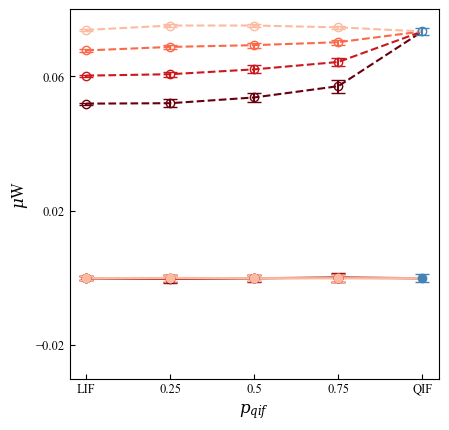

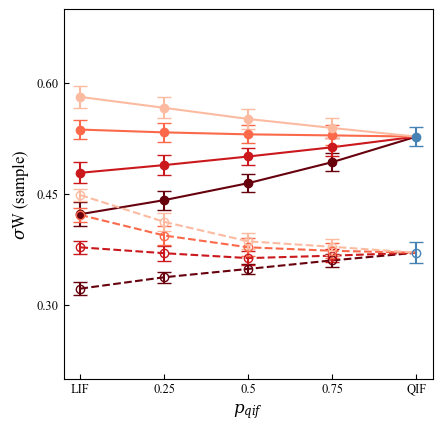

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib
from brokenaxes import brokenaxes
import matplotlib.lines as mlines
from pathlib import Path

# Load matplotlib style
plt.style.use('plos.mplstyle')

# Import and load color map
from color_map import make_color_map
v_rest = [-22, -17, -12.3, -8.5]
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest

pqif_vector = [0, 0.25, 0.5, 0.75, 1]
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'

# Base path
base_path = Path(r"J:\ordinary_simulations")  # ordinary simulations
base_path.mkdir(parents=True, exist_ok=True)

# Figure path
figure_folder = 'figures_all/figures_june'
figure_folder = 'figures_all/final_figures_thesis'  # Figure path
loaded_df = pd.read_csv("statistics_connectivity.csv")  # Get csv with the stats

wDF = loaded_df.copy()


# ------------------------------------------------------------

# Loop variables 

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]
pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]
dynamics = ['oscillations', 'sequences']
seed_number = [i for i in range(0, 50)]
columns = ['mean', 'std_sample']
x_ticks = ['LIF', 0.25, 0.5, 0.75, 'QIF']

# ------------------------------------------------------------

# Figure loop


for c in columns:

    fig, ax = plt.subplots()  # Both dynamics should be in the same figure for this one
    figname = f"both_heterogenous_{c}-vs-pqif_filtered.svg"

    for dyn in dynamics:
        
        simulation_number, fillstyle, linestyle = ([i for i in range(1,5)], 'full', '-') if dyn == 'oscillations' else ([i for i in range(9,13)], 'none', '--')


        for sim, vr, f in zip(simulation_number, vrest, slope):
        

            y = []
            yerr = []
            x = pqif_number

            for pqif in pqif_number:


                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif)]  # Current row of dataframe with metadata. Include all seeds since we want errorbars

                # Y: Mean of Y
                y_i = df_filtered[c].mean()

                # Y-error: STD of Y
                yerr_i = df_filtered[c].std()  # sample std by default


                y.append(y_i)
                yerr.append(yerr_i)


            if (sim == simulation_number[0]):
                label = f"LIF\n$F'$={f}"
            else:
                label = f"$F'$={f}"

            if dyn == 'sequences':
                label = None


            ########## For formatting purposes, I plot double to allow connecting lines to QIF without having errorbars on top of eachother for QIF specifically ##########

            no_qif_x = x[:-1]
            no_qif_y = y[:-1]
            no_qif_yerr = yerr[:-1]


            ax.errorbar(no_qif_x, no_qif_y, no_qif_yerr, fmt='o', fillstyle=fillstyle, capsize=5, color=color_map_vrest[vr], label=label)
            ax.plot(x, y, linestyle=linestyle, color=color_map_vrest[vr], label=None)

        
        ########## Title and tick labels ##########

        if c == 'std_sample':
            xlabel = f"$p_{{qif}}$"
            ylabel = f"$\sigma$W (sample)"
            ax.set_yticks(np.linspace(0.3, 0.6, 3))
            ax.set_ylim(0.2, 0.7)

        elif c == "mean":
            xlabel = f"$p_{{qif}}$"
            ylabel = f"$\mu$W"
            # ax.set_ylim(-0.08, 0.08)
            ax.set_yticks(np.linspace(-0.02, 0.06, 3))
            ax.set_ylim(-0.03, 0.08)


        ########## Add QIF ##########
        df_filtered_qif = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == 1)]

        y_qif = df_filtered_qif[c].mean()  # y
        yerr_qif = df_filtered_qif[c].std()  # y-error
        x_qif = 1  # x

        if dyn == 'oscillations': # first
            label = f"QIF\n$F'$={slope_qif}"
        else:
            label = None


        ax.errorbar(x_qif, y_qif, yerr_qif, fmt='o', capsize=5, fillstyle=fillstyle, color='steelblue', label=label)


    ax.set_xlabel(xlabel)
    ax.set_xticks(pqif_number, x_ticks)
    ax.set_ylabel(ylabel)
    ax.set_box_aspect(1)

    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")
    plt.show()
